In [1]:
import sys
from pathlib import Path
root_dir = Path.cwd().parent

sys.path.append(str(root_dir))


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

from embedder import CNNVAE
from predictor import CarRacingSequenceDataset, PredictorTransformer

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 32
img_size = 96
in_channels = 3

vae = CNNVAE(in_channels=in_channels, latent_dim=latent_dim, img_size=img_size).to(device)
vae.load_state_dict(torch.load('../embedder/vae82.5.pt', map_location=device))
vae.eval()

CNNVAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
  )
  (fc_mu): Linear(in_features=9216, out_features=32, bias=True)
  (fc_logvar): Linear(in_features=9216, out_features=32, bias=True)
  (decoder_input): Linear(in_features=32, out_features=9216, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=(2, 2)

In [4]:
obs = torch.tensor(np.transpose(np.load('../try/observations-try0.npy.npy').astype(np.float32) / 255.0, (0, 3, 1, 2)))
act = np.array(np.load('../try/actions-try0.npy', allow_pickle=True), dtype=np.long)

In [5]:
obs = vae.reparameterize(*vae.encode(obs)).squeeze().detach()

In [24]:
act

array([[0, 0, 0, 0],
       [0, 0, 0, 6],
       [0, 0, 0, 0],
       ...,
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0]], shape=(10047, 4))

In [6]:
dataset = CarRacingSequenceDataset(
    obs=obs,
    act=act,
    seq_len=64
)

In [7]:
train_loader = DataLoader(dataset, batch_size=8)

In [8]:
len(train_loader)

1248

In [9]:
predictor = PredictorTransformer(32, 8, 128, 3, 1, 4, 64)

In [10]:
from torchinfo import summary

In [11]:
summary(predictor)

Layer (type:depth-idx)                   Param #
PredictorTransformer                     --
├─Linear: 1-1                            32
├─Linear: 1-2                            5,248
├─Linear: 1-3                            4,128
├─Linear: 1-4                            129
├─SinusoidalPositionalEncoding: 1-5      --
├─MultiHeadAttention: 1-6                --
│    └─Linear: 2-1                       16,512
│    └─Linear: 2-2                       16,512
│    └─Linear: 2-3                       16,512
│    └─Linear: 2-4                       16,512
│    └─Dropout: 2-5                      --
├─SimpleFFN: 1-7                         --
│    └─Linear: 2-6                       66,048
│    └─Linear: 2-7                       65,664
│    └─Dropout: 2-8                      --
│    └─GELU: 2-9                         --
├─LayerNorm: 1-8                         256
├─LayerNorm: 1-9                         256
├─Dropout: 1-10                          --
Total params: 207,809
Trainable params

In [12]:
optimizer = optim.Adam(predictor.parameters(), lr=1e-4)

In [13]:
predictor.train()
for epoch in range(50):
    total_loss_epoch = 0
    for batch in train_loader:
        Z_in = batch[0].to(device)
        A = batch[1].to(torch.float).to(device)
        reward_tgt = batch[2].to(torch.float).to(device)
        Z_tgt = batch[3].to(device)


        optimizer.zero_grad()
        Z_pred, reward = predictor(Z_in, A)
        loss_z = torch.nn.functional.mse_loss(Z_pred[:, -1, :], Z_tgt)
        loss_r = torch.nn.functional.mse_loss(reward[:, -1, :], reward_tgt)
        
        loss = loss_z + 0.1*loss_r
        
        loss.backward()
        optimizer.step()

        total_loss_epoch += loss.item()

    avg_loss = total_loss_epoch / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{50}, Average Loss: {avg_loss:.4f}")

/Users/daniilogorodnikov/DeepZero/predictor/model.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return obs_window, actions[:, :2], actions[:, 2:], torch.tensor(target_obs)


RuntimeError: mat1 and mat2 shapes cannot be multiplied (512x2 and 3x8)

In [16]:
reward_tgt.shape

torch.Size([8, 64, 1])

In [14]:
Z_tgt.shape

torch.Size([3, 32])

In [15]:
data_t = next(iter(train_loader))
acts = []
zets = []
outs = []
for z, a, in zip(data_t[0][0][:8], data_t[1][0][:8]):
    acts.append(a)
    zets.append(z)
    A = torch.stack(acts).unsqueeze(0).to(torch.float32)
    Z = torch.stack(zets).unsqueeze(0)
    out = predictor(Z, A)[:, -1, :]
    outs.append(out)

In [16]:
torch.stack(outs).squeeze(1).shape

torch.Size([8, 32])

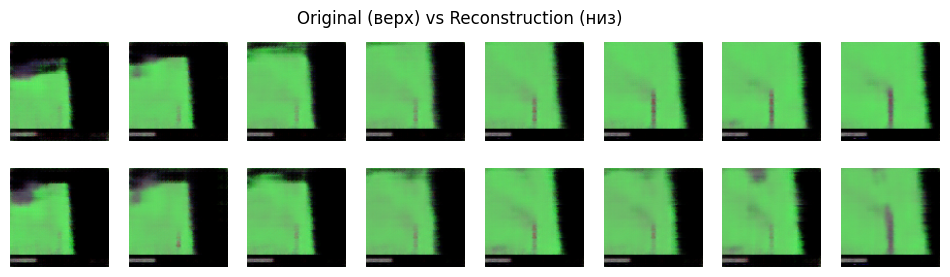

In [17]:
vae.eval()
with torch.no_grad():
    true_z = next(iter(train_loader))[0][0][:8].to(device)
    pred_z = torch.stack(outs).squeeze(1).to(device)
    recon_true_x = vae.decode(true_z)
    recon_prex_x = vae.decode(pred_z)
    
    test_x_cpu = recon_true_x.cpu().numpy()
    recon_x_cpu = recon_prex_x.cpu().numpy()

    fig, axes = plt.subplots(2, 8, figsize=(12, 3))
    for i in range(8):
        axes[0, i].imshow(np.transpose(test_x_cpu[i], (1, 2, 0)))
        axes[0, i].axis('off')
        axes[1, i].imshow(np.transpose(recon_x_cpu[i], (1, 2, 0)))
        axes[1, i].axis('off')
    plt.suptitle("Original (верх) vs Reconstruction (низ)")
    plt.show()

In [18]:
torch.save(predictor.state_dict(), "predictor.pt")

In [24]:
torch.randn(1, 32, dtype=torch.float32)

tensor([[-0.3694, -0.6612, -0.0772,  0.4362,  0.5835,  0.4301,  1.1496,  0.8357,
         -0.3967,  0.7473, -0.5491, -0.7342, -0.1434, -0.8309,  0.2948,  0.3111,
          0.8791,  0.8917, -0.0618,  2.3352,  0.9807, -0.6951,  0.9465,  0.4577,
          1.6295, -0.6217, -1.8637, -0.0578, -0.7523, -1.0921,  1.3310, -0.9420]])